In [1]:
import numpy as np
import matplotlib.pyplot as plt
import QST_core_processes as qst #type: ignore

### Generate data of states and associated measurements probabilities

In [15]:
N = 5000  # number of states
n_qubits = 2

rhos, taus = qst.generate_dataset_of_states_and_probabilities(N, n_qubits)
data = {'rhos': rhos, 'taus': taus}

### Setting up Projector Matrix and Simulating Shots

In [16]:
P = qst.build_projector_matrix(n_qubits)
P_noisy = qst.simulate_waveplate_misalignment(np.pi/6, P, n_qubits)

counts = []
n_shots = 100
for rho in data['rhos']:
    p = qst.get_measurement_probs_from_P_and_rho(rho, P_noisy, n_qubits)
    p_noisy = qst.simulate_interference_visibility(p, 0.97)
    counts.append(qst.retrieve_counts_from_n_shots_per_state(p_noisy, n_shots))

data['counts'] = np.stack(counts, axis=0) # easier to work with as a single array
data['P'] = P
data['shots'] = n_shots

In [17]:
def split_data_dict(data, train_ratio=0.8, seed=0):
    """
    Split a data dictionary into train and test subsets.
    Args:
        data: dict with keys "rhos", "counts", "shots", "P", and optionally "taus".
        train_ratio: fraction of data to use for training.
        seed: random seed for reproducibility.

    Returns:
        data_train: dict with training data.
        data_test: dict with test data.
        train_idx: indices of training samples in original data.
        test_idx: indices of test samples in original data.
    """
    rng = np.random.default_rng(seed)
    N = len(data["rhos"])
    idx = rng.permutation(N)
    split = int(train_ratio * N)
    train_idx, test_idx = idx[:split], idx[split:]

    def subset(key, inds):
        arr = data[key]
        if isinstance(arr, list):
            return [arr[i] for i in inds]
        # object arrays or stacked arrays both work with indexing
        return arr[inds]

    data_train = {
        "rhos": subset("rhos", train_idx),
        "counts": subset("counts", train_idx),
        "shots": data["shots"],
        "P": data["P"],
    }
    # taus only if you have them
    if "taus" in data:
        data_train["taus"] = subset("taus", train_idx)

    data_test = {
        "rhos": subset("rhos", test_idx),
        "counts": subset("counts", test_idx),
        "shots": data["shots"],
        "P": data["P"],
    }
    if "taus" in data:
        data_test["taus"] = subset("taus", test_idx)

    return data_train, data_test, train_idx, test_idx

data_train, data_test, train_idx, test_idx = split_data_dict(data, train_ratio=0.8, seed=42)

This completes the 'setup' portion

For each set of shots data, must then:
- attempt to reconstruct rho using either stokes or Deep Learning
- (ensure consistency in storage)
- compare resulting density matrices with the actual density matrices stored originally

### Implementing Stokes Reconstruction

In [21]:
outputs = {}
outputs['stokes_rhos'] = qst.stokes_reconstruct_dataset(
    P = data_test['P'],
    counts = data_test['counts'],
    shots = data_test['shots'],
    n_qubits = n_qubits
)

In [19]:
# Naive Neural Network approach
nn_naive = qst.NN_Builder(
    n_qubits=n_qubits,
    model_type="mlp",
    loss_type="mse",
    target="rho",
    hidden_sizes=(256, 256, 256),
    dropout=0.1,
    lr=1e-3,
    batch_size=64,
    epochs=200
)

outputs['nn_naive_history'] = nn_naive.fit(data_train)
outputs['nn_naive_rhos'] = nn_naive.predict(data_test)


Epoch 1/200, Loss: 0.4908
Epoch 20/200, Loss: 0.2300
Epoch 40/200, Loss: 0.2140
Epoch 60/200, Loss: 0.2009
Epoch 80/200, Loss: 0.1890
Epoch 100/200, Loss: 0.1794
Epoch 120/200, Loss: 0.1705
Epoch 140/200, Loss: 0.1630
Epoch 160/200, Loss: 0.1587
Epoch 180/200, Loss: 0.1543
Epoch 200/200, Loss: 0.1510


In [7]:
# Physics-informed Neural Network approach
nn_phys = qst.NN_Builder(
    n_qubits=n_qubits,
    model_type="mlp",
    loss_type="fidelity",
    target="tau",
    hidden_sizes=(256, 256, 256),
    dropout=0.1,
    lr=1e-3,
    batch_size=64,
    epochs=200
)

outputs['nn_phys_history'] = nn_phys.fit(data_train)
outputs['nn_phys_rhos'] = nn_phys.predict(data_test)

Epoch 1/200, Loss: 17.6907
Epoch 20/200, Loss: 8.7077
Epoch 40/200, Loss: 7.9576
Epoch 60/200, Loss: 7.4617
Epoch 80/200, Loss: 7.1672
Epoch 100/200, Loss: 6.8929
Epoch 120/200, Loss: 6.5894
Epoch 140/200, Loss: 6.3913
Epoch 160/200, Loss: 6.2553
Epoch 180/200, Loss: 6.0385
Epoch 200/200, Loss: 5.9792


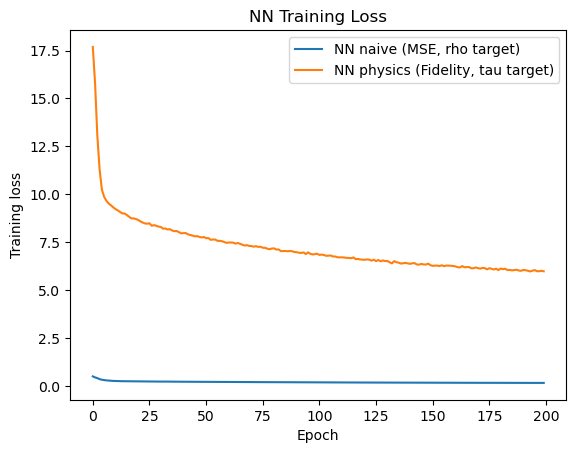

In [8]:
plt.figure()
plt.plot(outputs["nn_naive_history"]["loss"], label="NN naive (MSE, rho target)")
plt.plot(outputs["nn_phys_history"]["loss"], label="NN physics (Fidelity, tau target)")
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("NN Training Loss")
plt.legend()
plt.show()

In [22]:
# Compute fidelities

true_rhos = data_test["rhos"]

def fidelities_vs_truth(pred_rhos):
    return np.array([qst.fidelity(true_rhos[k], pred_rhos[k]) for k in range(len(true_rhos))])

F_stokes = fidelities_vs_truth(outputs["stokes_rhos"])
F_naive  = fidelities_vs_truth(outputs["nn_naive_rhos"])
F_phys   = fidelities_vs_truth(outputs["nn_phys_rhos"])

KeyError: 'nn_naive_rhos'

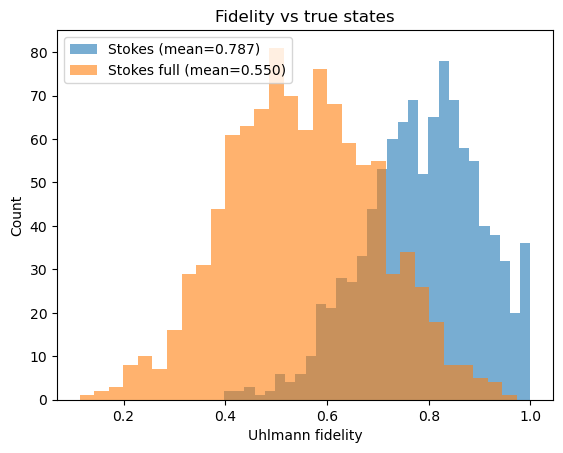

Mean fidelities:
  Stokes: 0.7872685070107147 std: 0.11363637063627809


In [ ]:
plt.figure()
plt.hist(F_stokes, bins=30, alpha=0.6, label=f"Stokes (mean={F_stokes.mean():.3f})")
plt.hist(F_naive,  bins=30, alpha=0.6, label=f"NN naive (mean={F_naive.mean():.3f})")
plt.hist(F_phys,   bins=30, alpha=0.6, label=f"NN physics (mean={F_phys.mean():.3f})")

plt.xlabel("Uhlmann fidelity")
plt.ylabel("Count")
plt.title("Fidelity vs true states")
plt.legend()
plt.show()


print("Mean fidelities:")
print("  Stokes:", F_stokes.mean(), "std:", F_stokes.std())
print("  Naive :", F_naive.mean(),  "std:", F_naive.std())
print("  Phys  :", F_phys.mean(),   "std:", F_phys.std())